## Classificatore Real+Synthetic — MaxViT-Tiny-512 con Fine-Tuning (Sblocco Totale del Backbone)

Classificatore binario (cancro / non cancro) su mammografie con **MaxViT-Tiny-512** (`timm`, pre-addestrato
`in1k`) e training in due fasi, sugli stessi dati reali + sintetici (fine-tuned SD2.1) usati dai notebook
ResNet-50 [`06`](06_Classificatore_RealSynthetic_ResNet-50_FineTuned.ipynb) /
[`06b`](06b_Classificatore_RealSynthetic_ResNet-50_FineTuned_Full.ipynb).

1. **Head Training** — backbone congelato, si addestra solo la testa. Loss `BCEWithLogitsLoss` (pos_weight bilanciato), Adam lr=1e-3.
2. **Fine-Tuning** — sblocco totale del backbone. Loss `BinaryFocalLoss` (γ=2, α=0.75), Adam lr=1e-5 con `ReduceLROnPlateau`.

I dati di train sono reali preprocessati + sintetici generati dal diffusore fine-tuned.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys

# Controlla se il notebook sta girando su Google Colab
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import Librerie

In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from datetime import date
from sklearn.metrics import (confusion_matrix, roc_curve, classification_report,
                              roc_auc_score, precision_score, recall_score, f1_score)

sys.path.insert(0, os.getcwd())
from maxvit_utils import (
    MODEL_NAME, build_maxvit_model, resolve_normalization, make_dataloader,
    freeze_all, unfreeze_head, unfreeze_stages_from, unfreeze_all, count_trainable_params,
    BinaryFocalLoss, compute_pos_weight, EarlyStopping, ModelCheckpoint, CSVLogger,
    fit, predict_probs, optimal_threshold_youden, make_gradcam_heatmap, show_gradcam,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


#### Download immagini sintetiche (fine-tuned)

Scarica da Google Drive lo ZIP con le immagini sintetiche positive e negative, le estrae nelle rispettive cartelle e rimuove l'archivio.
Se le immagini sono già presenti in locale, il download viene saltato

In [3]:
DEST_DIR     = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')
DEST_DIR_POS = os.path.join(DEST_DIR, 'positive')
DEST_DIR_NEG = os.path.join(DEST_DIR, 'negative')
ZIP_PATH     = os.path.join(DEST_DIR, 'filtered_generated.zip')
SYNTHETIC_DRIVE_ID = '1NKXKcovSlS4-0_zznKmrg1nU0DiXhcFq'

ZIP_FOLDER_POS = 'positive_filtered_1361_adaptive_mask'
ZIP_FOLDER_NEG = 'negative_filtered_1361_adaptive_mask'

def synthetic_data_ready():
    if not os.path.isdir(DEST_DIR_POS) or not os.path.isdir(DEST_DIR_NEG):
        return False
    return (
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_POS)) and
        any(f.endswith('.png') for f in os.listdir(DEST_DIR_NEG))
    )

os.makedirs(DEST_DIR, exist_ok=True)

if not synthetic_data_ready():
    import shutil, tempfile
    print("Immagini sintetiche non trovate, scarico da Google Drive...")
    gdown.download(id=SYNTHETIC_DRIVE_ID, output=ZIP_PATH, quiet=False)

    with tempfile.TemporaryDirectory() as tmp:
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(tmp)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_POS), DEST_DIR_POS)
        shutil.move(os.path.join(tmp, ZIP_FOLDER_NEG), DEST_DIR_NEG)

    os.remove(ZIP_PATH)
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Estrazione completata. File presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")
else:
    n_pos = sum(1 for f in os.listdir(DEST_DIR_POS) if f.endswith('.png'))
    n_neg = sum(1 for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png'))
    print(f"Immagini sintetiche già presenti:\n - Positivi: {n_pos}\n - Negativi: {n_neg}")

Immagini sintetiche già presenti:
 - Positivi: 1361
 - Negativi: 1361


#### Verifica presenza dataset preprocessato

Verifica se il dataset preprocessato è già presente in locale (CSV + immagini). Se non lo trova, scarica il file `.zip` da Google Drive tramite `gdown`, lo estrae nella cartella `data/processed/` e rimuove l'archivio.

In [4]:
# ID del file su Google Drive (stesso dataset preprocessato usato dai classificatori ResNet-50)
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download")

Dataset già presente, salto il download


#### Creazione CSV combinato (reale + sintetico)

Costruisce il training set combinato bilanciando le classi al 45% positivi / 55% negativi:
- Positivi: tutte le immagini reali positive + tutte le sintetiche positive
- Negativi: tutte le immagini reali negative + un sottoinsieme di sintetiche negative,
  campionato deterministicamente con `np.linspace` per coprire uniformemente la distribuzione

In [5]:
OUTPUT_PATH = os.path.join(BASE_PATH, 'data', 'synthetic', 'metadata', 'train_real_synthetic_ft.csv')
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_real_train = pd.read_csv(TRAIN_CSV_PATH)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_real_train['processed_path'] = df_real_train['processed_path'].apply(fix_path)

n_real_pos = (df_real_train['cancer'] == 1).sum()
n_real_neg = (df_real_train['cancer'] == 0).sum()

synth_pos_paths = sorted([
    os.path.join(DEST_DIR_POS, f)
    for f in os.listdir(DEST_DIR_POS) if f.endswith('.png')
])
n_synth_pos = len(synth_pos_paths)

# Logica di bilanciamento 45% positivi / 55% negativi
tot_pos = n_real_pos + n_synth_pos
tot_dataset = round(tot_pos / 0.45)
tot_neg_needed = tot_dataset - tot_pos
n_synth_neg_needed = max(0, tot_neg_needed - n_real_neg)

synth_neg_paths_all = sorted([
    os.path.join(DEST_DIR_NEG, f)
    for f in os.listdir(DEST_DIR_NEG) if f.endswith('.png')
])
n_available = len(synth_neg_paths_all)

if n_synth_neg_needed > n_available:
    print(f"ATTENZIONE: richieste {n_synth_neg_needed} sintetiche negative, disponibili {n_available}. Uso tutte.")
    synth_neg_paths = synth_neg_paths_all
else:
    indices = np.linspace(0, n_available - 1, n_synth_neg_needed, dtype=int)
    synth_neg_paths = [synth_neg_paths_all[i] for i in indices]

df_synth_pos_df = pd.DataFrame({'processed_path': synth_pos_paths, 'cancer': 1, 'type': 'generated_ft'})
df_synth_neg_df = pd.DataFrame({'processed_path': synth_neg_paths,  'cancer': 0, 'type': 'generated_ft'})

df_combined = pd.concat(
    [df_real_train.assign(type='real'), df_synth_pos_df, df_synth_neg_df],
    ignore_index=True
)
df_combined.to_csv(OUTPUT_PATH, index=False)
df_synth = pd.concat([df_synth_pos_df, df_synth_neg_df], ignore_index=True)
print(f"Dataset combinato: {len(df_combined)} immagini ({(df_combined.cancer==1).sum()} positive, {(df_combined.cancer==0).sum()} negative)")

Dataset combinato: 3780 immagini (1701 positive, 2079 negative)


#### Analisi esplorativa del dataset combinato

              No cancro (0)  Cancro (1)  Totale  % cancer=1
Tipo                                                       
generated_ft            378        1361    1739        78.3
real                   1701         340    2041        16.7


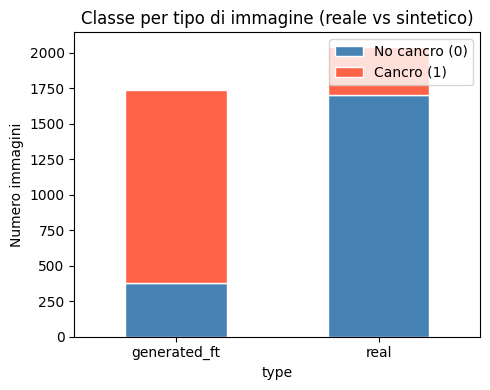

In [6]:
ct = pd.crosstab(df_combined['type'], df_combined['cancer'], rownames=['Tipo'], colnames=['cancer'])
ct.columns = ['No cancro (0)', 'Cancro (1)']
ct['Totale'] = ct.sum(axis=1)
ct['% cancer=1'] = (ct['Cancro (1)'] / ct['Totale'] * 100).round(1)
print(ct.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
ct_plot = pd.crosstab(df_combined['type'], df_combined['cancer'])
ct_plot.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'tomato'], rot=0, edgecolor='white')
ax.set_title('Classe per tipo di immagine (reale vs sintetico)')
ax.set_ylabel('Numero immagini')
ax.legend(['No cancro (0)', 'Cancro (1)'], loc='upper right')
plt.tight_layout()
plt.show()

#### Configurazione

In [7]:
# Cartella esperimento
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/maxvit512/02c_real_synth_full')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(OUTPUT_DIR)

../experiments/exp_maxvit512_real_synth_full


#### Configurazione

In [8]:
IMG_SIZE = 512          # input nativo di maxvit_tiny_tf_512
BATCH_SIZE = 8          # ridotto rispetto a ResNet-50 (224x224): 512x512 su MaxViT richiede piu' VRAM
SEED = 42

# Normalizzazione attesa per maxvit_tiny_tf_512.in1k (verificata a runtime dopo la costruzione del modello)
IMAGENET_MEAN = (0.5, 0.5, 0.5)
IMAGENET_STD = (0.5, 0.5, 0.5)

torch.manual_seed(SEED)
np.random.seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


#### Preparazione Dataset e Pipeline di Input

Costruisce i `DataLoader` PyTorch di train/validation. Preprocessing applicato ad ogni immagine:
decodifica in scala di grigi, resize a 512×512, replica su 3 canali, normalizzazione (mean=std=0.5).
Augmentation (opzionale, disabilitata di default): flip orizzontale e variazione di luminosità —
stesse scelte del progetto ResNet-50 (niente rotazioni/zoom per non introdurre artefatti irrealistici).

In [9]:
df_train = pd.read_csv(OUTPUT_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_train['processed_path'] = df_train['processed_path'].apply(fix_path)
df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

In [10]:
train_loader = make_dataloader(
    df_train, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, augment=False, seed=SEED,
)
val_loader = make_dataloader(
    df_val, 'processed_path', 'cancer', IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
)

n_pos = int((df_train['cancer'] == 1).sum())
n_neg = int((df_train['cancer'] == 0).sum())
print(f"Train: {len(df_train)} immagini (cancer=1: {n_pos}, cancer=0: {n_neg})")
print(f"Val:   {len(df_val)} immagini")

Train: 3780 immagini (cancer=1: 1701, cancer=0: 2079)
Val:   437 immagini


#### Configurazione e Salvataggio dell'Esperimento

In [11]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "maxvit_tiny_tf_512.in1k",
        "library": "timm",
        "weights": "in1k",
        "input_shape": [IMG_SIZE, IMG_SIZE, 3],
    },
    "head": {
        "type": "timm NormMlpClassifierHead",
        "pooling": "avg",
        "pre_logits": "Linear(512) + Tanh",
        "dropout": 0.0,
        "output": "Linear(1) [logits, BCEWithLogitsLoss]",
    },
    "preprocessing": {
        "img_size": [IMG_SIZE, IMG_SIZE],
        "normalization": "mean=std=0.5 (timm in1k tf-style)",
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": OUTPUT_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "BCEWithLogitsLoss(pos_weight=balanced)",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalLoss(alpha=0.75, gamma=2.0)",
        "max_epochs": 30,
        "fine_tune_from": "tutti gli stage",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
    },
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")

Configurazione esperimento salvata in: ../experiments/exp_maxvit512_real_synth_full/experiment_config.json


#### Costruzione del Modello — Fase 1 (Head Training)

Backbone **MaxViT-Tiny-512** (`timm`, pre-addestrato `in1k`, input 512×512 RGB) con testa di classificazione
binaria integrata in timm (`NormMlpClassifierHead`: pooling → LayerNorm → Linear(512) → Tanh → Dropout → Linear(1)).

Fase 1: backbone (stem + 4 stage) completamente congelato, si addestra solo `model.head`.
`BCEWithLogitsLoss` con `pos_weight` bilanciato equivale al `class_weight='balanced'` usato per ResNet-50.

In [12]:
model = build_maxvit_model(num_classes=1, pretrained=True)
model.to(DEVICE)

resolved_mean, resolved_std, resolved_size = resolve_normalization(model)
assert resolved_size == IMG_SIZE, f"IMG_SIZE atteso {resolved_size}, trovato {IMG_SIZE}"
print(f"Normalizzazione modello: mean={resolved_mean}  std={resolved_std}  input_size={resolved_size}")

freeze_all(model)
unfreeze_head(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

Normalizzazione modello: mean=(0.5, 0.5, 0.5)  std=(0.5, 0.5, 0.5)  input_size=512
Parametri trainable (Fase 1): 264,193 / 30,537,097


#### Compilazione e Training — Fase 1 (Head Training)

In [13]:
pos_weight = compute_pos_weight(df_train['cancer'].values).to(DEVICE)
criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_fase1 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3
)

early_stop_fase1 = EarlyStopping(patience=7, mode='max', restore_best_weights=True)
checkpoint_fase1 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_synth_maxvit512_all_layers_fase1_best.pt'), mode='max')
csv_logger_fase1 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'))

history_phase1 = fit(
    model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
    epochs=25, device=DEVICE,
    early_stopping=early_stop_fase1, checkpoint=checkpoint_fase1, csv_logger=csv_logger_fase1,
)

Epoch 1/25 - loss: 0.5984 - auc: 0.8027 - val_loss: 0.5141 - val_auc: 0.6321
Epoch 2/25 - loss: 0.5438 - auc: 0.8408 - val_loss: 0.5028 - val_auc: 0.6330
Epoch 3/25 - loss: 0.5178 - auc: 0.8573 - val_loss: 0.5191 - val_auc: 0.6506
Epoch 4/25 - loss: 0.5039 - auc: 0.8656 - val_loss: 0.5396 - val_auc: 0.5867
Epoch 5/25 - loss: 0.4841 - auc: 0.8772 - val_loss: 0.5084 - val_auc: 0.6423
Epoch 6/25 - loss: 0.4663 - auc: 0.8858 - val_loss: 0.5387 - val_auc: 0.6614
Epoch 7/25 - loss: 0.4405 - auc: 0.8995 - val_loss: 0.5101 - val_auc: 0.6625
Epoch 8/25 - loss: 0.4297 - auc: 0.9046 - val_loss: 0.5335 - val_auc: 0.6311
Epoch 9/25 - loss: 0.3923 - auc: 0.9214 - val_loss: 0.5618 - val_auc: 0.6395
Epoch 10/25 - loss: 0.3654 - auc: 0.9327 - val_loss: 0.5502 - val_auc: 0.6384
Epoch 11/25 - loss: 0.3329 - auc: 0.9450 - val_loss: 0.6653 - val_auc: 0.6047
Epoch 12/25 - loss: 0.2920 - auc: 0.9588 - val_loss: 0.5968 - val_auc: 0.6286
Epoch 13/25 - loss: 0.2536 - auc: 0.9702 - val_loss: 0.6298 - val_auc: 0.

#### Fine-Tuning — Fase 2 (Sblocco Totale del Backbone)

Tutti gli stage di MaxViT vengono sbloccati (fine-tuning completo), analogamente alla variante
`_Full` di ResNet-50. `BinaryFocalLoss` (γ=2, α=0.75) concentra il training sui casi difficili;
`ReduceLROnPlateau` dimezza il LR se `val_auc` non migliora per 3 epoche.

In [14]:
unfreeze_all(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 2): {trainable:,} / {total:,}")

criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer_fase2 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-5
)
lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='max', factor=0.5, patience=3, min_lr=1e-7
)

early_stop_fase2 = EarlyStopping(patience=5, min_delta=1e-3, mode='max', restore_best_weights=True)
checkpoint_fase2 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_synth_maxvit512_all_layers_final_best.pt'), mode='max')
csv_logger_fase2 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'))

history_phase2 = fit(
    model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
    epochs=30, device=DEVICE,
    early_stopping=early_stop_fase2, checkpoint=checkpoint_fase2, csv_logger=csv_logger_fase2,
    lr_scheduler=lr_scheduler_fase2,
)

print(f"\nTraining completato. Il miglior modello e' salvato in: {os.path.join(OUTPUT_DIR, 'real_synth_maxvit512_all_layers_final_best.pt')}")

Parametri trainable (Fase 2): 30,537,097 / 30,537,097
Epoch 1/30 - loss: 0.0680 - auc: 0.8213 - val_loss: 0.0598 - val_auc: 0.5946
Epoch 2/30 - loss: 0.0465 - auc: 0.8868 - val_loss: 0.0572 - val_auc: 0.6462
Epoch 3/30 - loss: 0.0436 - auc: 0.9036 - val_loss: 0.0645 - val_auc: 0.6256
Epoch 4/30 - loss: 0.0375 - auc: 0.9293 - val_loss: 0.0672 - val_auc: 0.6448
Epoch 5/30 - loss: 0.0326 - auc: 0.9469 - val_loss: 0.0924 - val_auc: 0.6368
Epoch 6/30 - loss: 0.0262 - auc: 0.9667 - val_loss: 0.0815 - val_auc: 0.6491
Epoch 7/30 - loss: 0.0189 - auc: 0.9834 - val_loss: 0.1056 - val_auc: 0.6271
Epoch 8/30 - loss: 0.0161 - auc: 0.9881 - val_loss: 0.1549 - val_auc: 0.6259
Epoch 9/30 - loss: 0.0118 - auc: 0.9938 - val_loss: 0.1695 - val_auc: 0.6016
Epoch 10/30 - loss: 0.0063 - auc: 0.9985 - val_loss: 0.2280 - val_auc: 0.6130
Epoch 11/30 - loss: 0.0037 - auc: 0.9995 - val_loss: 0.2134 - val_auc: 0.6046
Early stopping all'epoca 11 (best val_auc=0.6491)

Training completato. Il miglior modello e' sal

#### Visualizzazione Curve di Training

Plot Loss e AUC (train vs validation) per entrambe le fasi, salvati in `figures/`.

Analisi Overfitting - Fase 1 (Head Training):
Grafico salvato in: ../experiments/exp_maxvit512_real_synth_full/figures/training_history_fase1.png


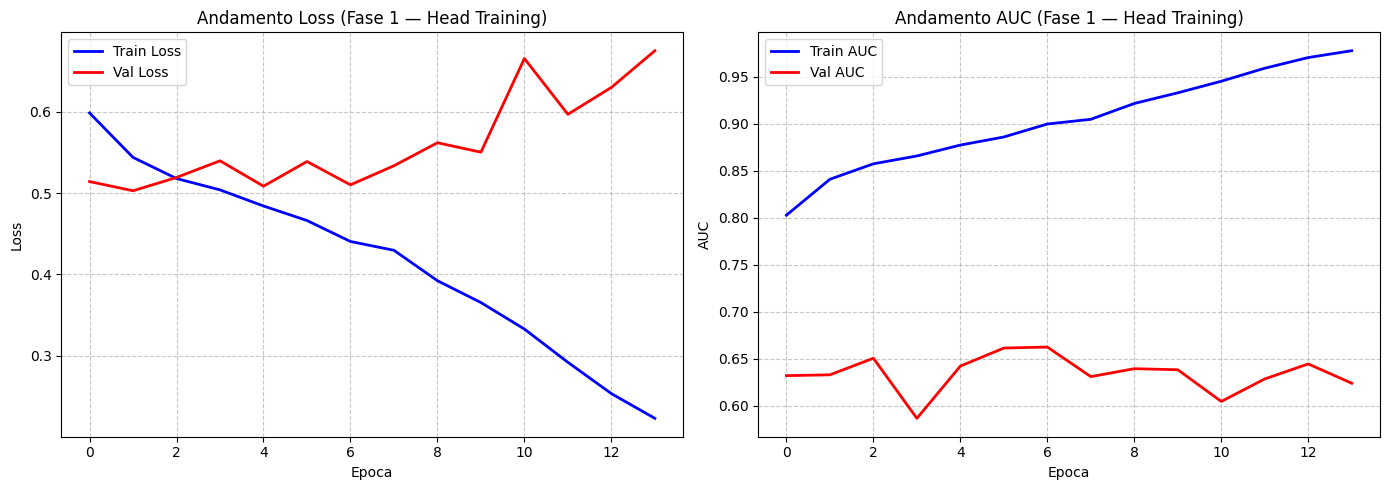

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp_maxvit512_real_synth_full/figures/training_history_fase2.png


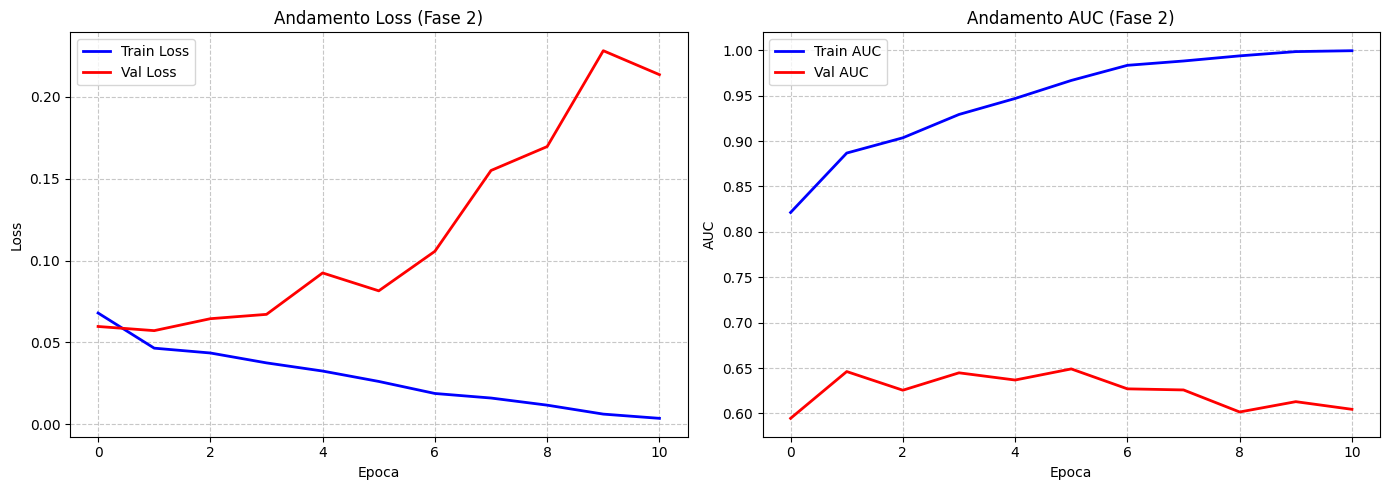

In [15]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Head Training):")
plot_training_history(
    history_phase1, "(Fase 1 — Head Training)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione sul Validation Set

Carica il miglior modello salvato e calcola le predizioni sull'intero validation set

- **Soglia ottimale**: indice di Youden (massimizza sensibilità + specificità)
- **Metriche**: AUC, precision, recall e F1 sulla classe positiva (cancro), salvate in `val_metrics.json`
- **Figure**: Confusion Matrix e ROC Curve salvate in `figures/`

AUC: 0.6491
Soglia ottimale: 0.275
              precision    recall  f1-score   support

   No cancro       0.92      0.40      0.56       364
      Cancro       0.22      0.82      0.34        73

    accuracy                           0.47       437
   macro avg       0.57      0.61      0.45       437
weighted avg       0.80      0.47      0.52       437

Metriche salvate in: ../experiments/exp_maxvit512_real_synth_full/val_metrics.json


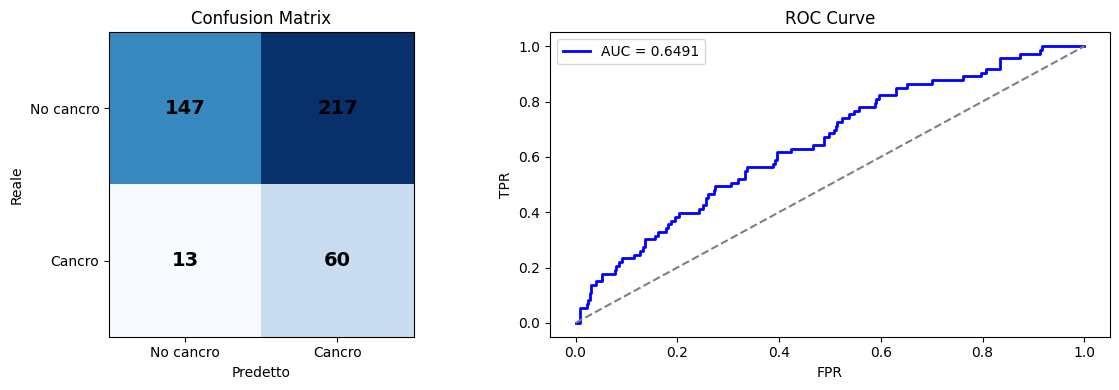

Figura salvata in: ../experiments/exp_maxvit512_real_synth_full/figures/val_confusion_roc.png


In [16]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'real_synth_maxvit512_all_layers_final_best.pt'), map_location=DEVICE))

y_true, y_pred_prob = predict_probs(model, val_loader, DEVICE)

best_threshold = optimal_threshold_youden(y_true, y_pred_prob)
y_pred = (y_pred_prob >= best_threshold).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

metrics_dict = {
    'split': 'validation',
    'backbone': 'MaxViT-Tiny-512',
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM — Interpretabilità del Modello

Visualizza le regioni dell'immagine che hanno maggiormente influenzato la predizione, calcolando i gradienti
dell'output rispetto all'ultima feature map spaziale del backbone (`model.forward_features`), analogamente
al Grad-CAM applicato a ResNet-50 sull'output convoluzionale finale.

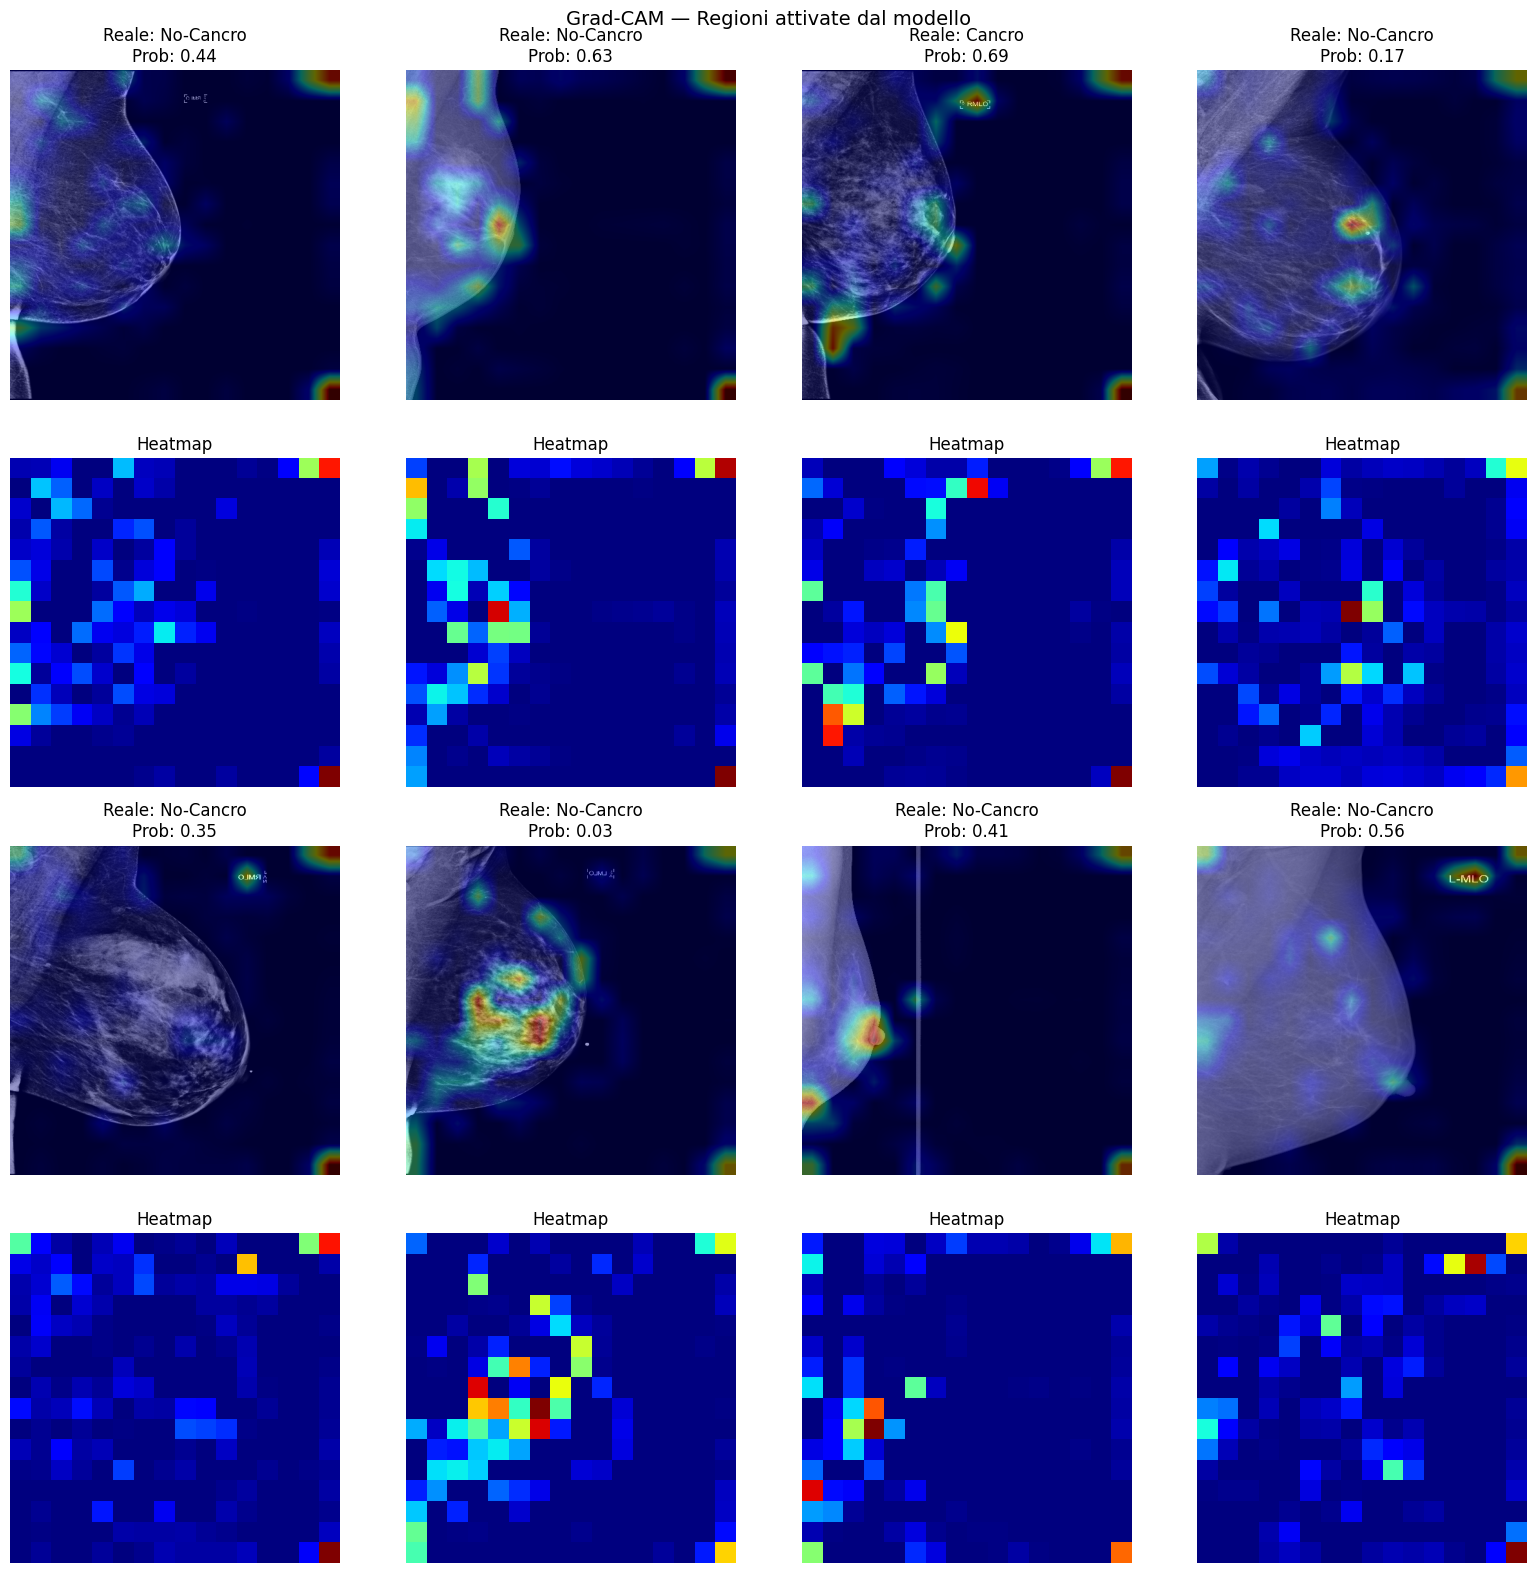

Grad-CAM salvato in: ../experiments/exp_maxvit512_real_synth_full/figures/gradcam_examples.png


In [17]:
# Mostra Grad-CAM su 8 esempi
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_loader:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i]
        label = int(labels[i].item())
        with torch.no_grad():
            prob = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE)).squeeze(-1)).item()
        heatmap = make_gradcam_heatmap(model, img, DEVICE)

        row_img = (sample_count // 4) * 2
        row_heat = row_img + 1
        col = sample_count % 4

        show_gradcam(img, heatmap, axes[row_img, col], IMAGENET_MEAN, IMAGENET_STD,
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")

#### Grad-CAM su immagini sintetiche

Applica Grad-CAM a 8 immagini sintetiche campionate casualmente (seed fisso), per verificare se il modello
attiva regioni anatomicamente plausibili anche sulle immagini generate.

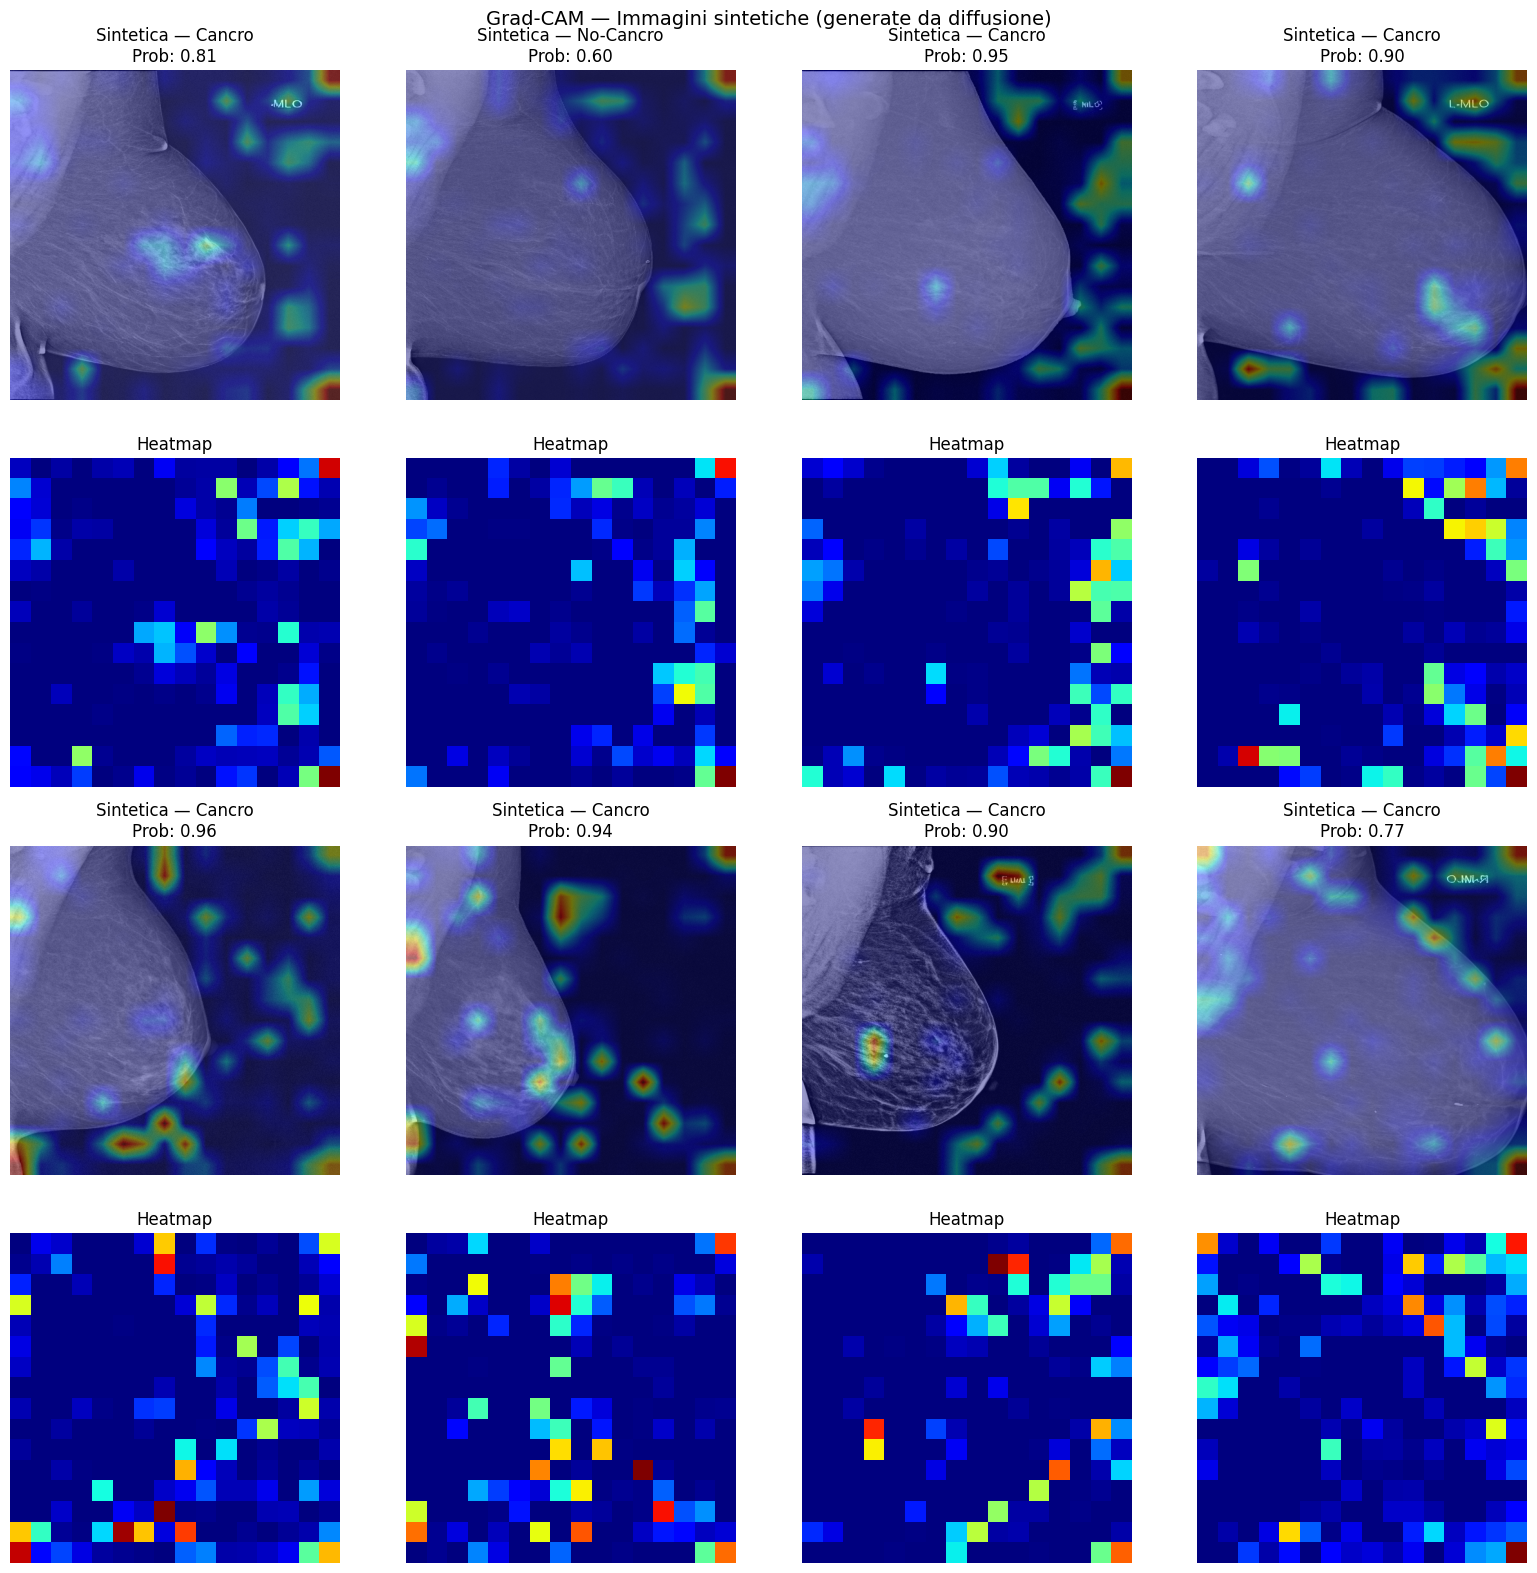

Grad-CAM sintetiche salvato in: ../experiments/exp_maxvit512_real_synth_full/figures/gradcam_synthetic_examples.png


In [18]:
synth_loader = make_dataloader(
    df_synth[['processed_path', 'cancer']], 'processed_path', 'cancer',
    IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False,
)

all_synth_imgs, all_synth_labels = [], []
for imgs, labels in synth_loader:
    for i in range(len(imgs)):
        all_synth_imgs.append(imgs[i])
        all_synth_labels.append(int(labels[i].item()))

np.random.seed(SEED)
indices_synth = np.random.choice(len(all_synth_imgs), size=8, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for i, idx in enumerate(indices_synth):
    img = all_synth_imgs[idx]
    label = all_synth_labels[idx]
    with torch.no_grad():
        prob = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE)).squeeze(-1)).item()
    heatmap = make_gradcam_heatmap(model, img, DEVICE)

    row_img = (i // 4) * 2
    row_heat = row_img + 1
    col = i % 4

    show_gradcam(img, heatmap, axes[row_img, col], IMAGENET_MEAN, IMAGENET_STD,
                 title=f"Sintetica — {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
    axes[row_heat, col].imshow(heatmap, cmap='jet')
    axes[row_heat, col].set_title("Heatmap")
    axes[row_heat, col].axis('off')

plt.suptitle("Grad-CAM — Immagini sintetiche (generate da diffusione)", fontsize=14)
plt.tight_layout()
gradcam_synth_path = os.path.join(FIGURES_DIR, 'gradcam_synthetic_examples.png')
fig.savefig(gradcam_synth_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM sintetiche salvato in: {gradcam_synth_path}")